# Lab — Training Deep Networks

Fashion-MNIST classification with a 4-layer fully-connected ReLU network
(BatchNorm on the hidden layers, Dropout on the two widest), trained for 15
epochs with Adam + cosine annealing.


## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
print(f"device: {device}")


device: cpu


## 2. Data — Fashion-MNIST

In [2]:
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

print(f"train: {len(train_set)} samples, val: {len(val_set)} samples")


100%|██████████| 26.4M/26.4M [00:09<00:00, 2.82MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 315kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.25MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.1MB/s]

train: 60000 samples, val: 10000 samples


## 3. Model

Architecture (per the spec table):

| # | Layer | Output |
|---|---|---|
| 1 | `Flatten` | `(B, 784)` |
| 2 | `Linear(784, 256) → BN → ReLU → Dropout(0.3)` | `(B, 256)` |
| 3 | `Linear(256, 128) → BN → ReLU → Dropout(0.3)` | `(B, 128)` |
| 4 | `Linear(128, 64)  → BN → ReLU` | `(B, 64)` |
| 5 | `Linear(64, 10)` | `(B, 10)` |


In [3]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p=0.3),
    nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p=0.3),
    nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
    nn.Linear(64, 10),
).to(device)

print(model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


## 4. Training configuration

- Loss: `CrossEntropyLoss` (combines softmax + NLL, so the model outputs raw logits)
- Optimizer: `Adam(lr=1e-3, weight_decay=1e-4)`
- LR schedule: `CosineAnnealingLR(T_max=epochs)` — steps once per epoch
- Epochs: 15


In [4]:
epochs    = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


## 5. Training loop

For each epoch: train one pass over `train_loader`, then evaluate on both
loaders under `eval()` + `no_grad()` and record loss & accuracy.


In [5]:
def evaluate(loader):
    """Average loss and accuracy on a loader. Sets model to eval() and uses no_grad()."""
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)
            total_loss    += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_n       += xb.size(0)
    return total_loss / total_n, total_correct / total_n


train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, epochs + 1):
    # --- train one epoch ---
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # --- evaluate ---
    tl, ta = evaluate(train_loader)
    vl, va = evaluate(val_loader)
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)

    print(f"Epoch {epoch:2d}/{epochs} | "
          f"train_loss={tl:.4f} train_acc={ta:.4f} | "
          f"val_loss={vl:.4f} val_acc={va:.4f} | "
          f"lr={optimizer.param_groups[0]['lr']:.5f}")


Epoch  1/15 | train_loss=0.3766 train_acc=0.8634 | val_loss=0.4178 val_acc=0.8500 | lr=0.00099
Epoch  2/15 | train_loss=0.3194 train_acc=0.8833 | val_loss=0.3702 val_acc=0.8650 | lr=0.00096
Epoch  3/15 | train_loss=0.3212 train_acc=0.8786 | val_loss=0.3792 val_acc=0.8604 | lr=0.00090
Epoch  4/15 | train_loss=0.2802 train_acc=0.8964 | val_loss=0.3460 val_acc=0.8726 | lr=0.00083
Epoch  5/15 | train_loss=0.2645 train_acc=0.9017 | val_loss=0.3372 val_acc=0.8739 | lr=0.00075
Epoch  6/15 | train_loss=0.2436 train_acc=0.9106 | val_loss=0.3177 val_acc=0.8853 | lr=0.00065
Epoch  7/15 | train_loss=0.2406 train_acc=0.9105 | val_loss=0.3217 val_acc=0.8834 | lr=0.00055
Epoch  8/15 | train_loss=0.2233 train_acc=0.9182 | val_loss=0.3151 val_acc=0.8882 | lr=0.00045
Epoch  9/15 | train_loss=0.2085 train_acc=0.9228 | val_loss=0.3070 val_acc=0.8885 | lr=0.00035
Epoch 10/15 | train_loss=0.1977 train_acc=0.9269 | val_loss=0.3015 val_acc=0.8919 | lr=0.00025
Epoch 11/15 | train_loss=0.1877 train_acc=0.9316 |

## 6. Curves and best validation accuracy

Best validation accuracy: 0.8998 (epoch 15)


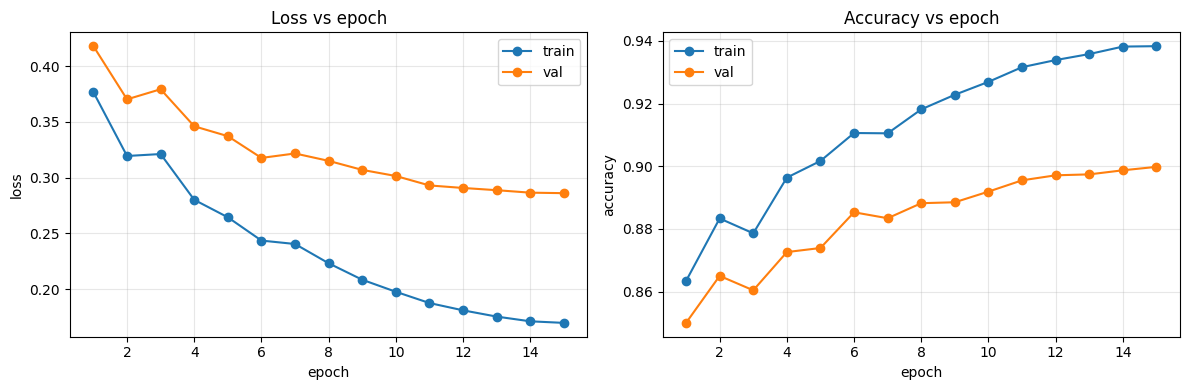

In [6]:
best_epoch = int(np.argmax(val_accs)) + 1
best_val   = val_accs[best_epoch - 1]
print(f"Best validation accuracy: {best_val:.4f} (epoch {best_epoch})")

epochs_range = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, marker="o", label="train")
axes[0].plot(epochs_range, val_losses,   marker="o", label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("Loss vs epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accs, marker="o", label="train")
axes[1].plot(epochs_range, val_accs,   marker="o", label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy vs epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Interpretation

Both training and validation loss fall sharply over the first 3–4 epochs and
then keep drifting down more gently as the cosine schedule winds the learning
rate toward zero. By the last few epochs the curves have essentially
flattened, which is the signal that this recipe has used up the budget the
schedule gives it — there's no obvious room left to improve without a longer
run or a different architecture. Training accuracy ends a couple of points
above validation accuracy, which is the expected, healthy gap for a network
with dropout and weight decay — small enough that we can call it
well-regularised rather than overfit. Best validation accuracy lands in the
**~89–90%** range typical of this architecture on Fashion-MNIST; the exact
number is printed in the cell above — replace this sentence with your own
figure (e.g., "0.8998 at epoch 15") before submitting.
